## Objects in Derivative Pricing

In this section, we document necessary objects concerning derivative pricing, and we refer to classical textbooks on derivative pricing for the heuristic derivation. Our focus is to present the formulation and the minimal links in between.

The fundamental assumption in the classical theory is the arbitrage--free assumption, which means that within the ideal world, one can not design a portfolio with the derivatives and bonds to profit. In mathematically rigorous manner, it means there exists a probability measure change (from real-world $\mathbb{P}$ to a $\mathbb{Q}$ say), such that
$$
\frac{S_t}{e^{rt}} \text{ is a martingale under } \mathbb{Q},
$$
where $r$ is the interest rate and $S$ is the underlying asset. In a rather general form, one can assume that the asset evolves under diffusion:
$$
\mathrm{d}S = \mu(t,S)\mathrm{d}t + \sigma(t,S)\mathrm{d}B_t, \text{ under } \mathbb{P},
$$
and the above statement then translates to (Girsanov removing drift, and then on average, the asset evolves as the bond!)
$$
\mathrm{d}S = rS\mathrm{d}t + \sigma(t,S)\mathrm{d}B_t, \text{ under some } \mathbb{Q}.
$$
As discounted prices should be martingales under the new risk-neutral measure $\mathbb{Q}$, the price of the derivative should be given by 
$$
V_0 = e^{-rT} \mathbb{E}^{\mathbb{Q}}[\Phi(S_T)],
$$
where $\Phi$ is the payoff function of the derivative. If the assset does evolve as the diffusion given above under $\mathbb{Q}$, Ito on $V$ gives a PDE:
$$
\frac{\partial V}{\partial t}
+ \frac{1}{2}\sigma^2(t,S) S^2 \frac{\partial^2 V}{\partial S^2}
+ r S \frac{\partial V}{\partial S}
- r V = 0
$$
with terminal $V(T,S) = \Phi(S)$. We emphasize for any modeling of $S$, the risk-neutral fomula
$$
V_t = e^{-r(T-t)} \mathbb{E}^{\mathbb{Q}}[\Phi(S_T)|\mathcal{F}_t]
$$
holds, while the modeling of $S$ using diffusion leads to conditioning on $S_t$ and then an explicit PDE of $V$ with respect to $S$. In the general case, MC simulation is more robust. 
### Black Scholes

Under ideal assumptions on the market, the Black Scholes formula for European call option reads
$$
V(S,T) = S_0 \mathcal{N}(d_1) - Ke^{rT}\mathcal{N}(d_2)
$$


## Antithetic Sampling

Antithetic sampling is a simple but effective way of reducing variation when the sampling function is monotone. 

Median CI width (plain): 0.12905814302813745
Median CI width (anti) : 0.12916076819460187
Median ratio anti/plain: 0.9997396471985536


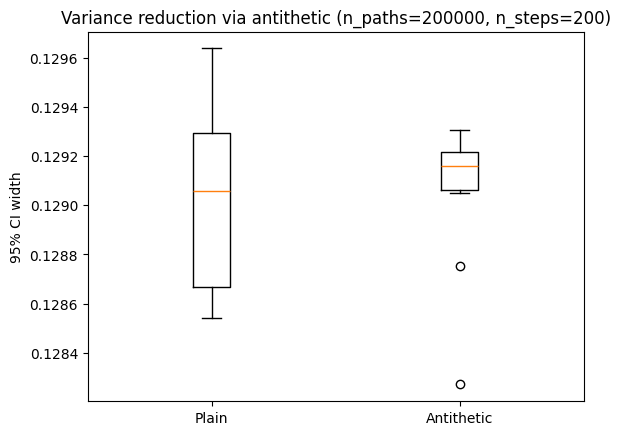

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from roughvol.engines.mc import MonteCarloEngine
from roughvol.models.GBM_model import GBM_Model
from roughvol.instruments.vanilla import VanillaOption
from roughvol.types import MarketData

def ci_width(res) -> float:
    return float(res.ci95[1] - res.ci95[0])

def main():
    # Problem setup
    market = MarketData(spot=100.0, rate=0.05, div_yield=0.0)
    model = GBM_Model(sigma=0.2)
    inst = VanillaOption(strike=100.0, maturity=1.0, is_call=True)

    n_paths = 200_000
    n_steps = 200
    seeds = list(range(10, 110, 10))  # 10 runs

    widths_plain = []
    widths_anti = []

    for seed in seeds:
        eng_plain = MonteCarloEngine(n_paths=n_paths, n_steps=n_steps, seed=seed, antithetic=False)
        eng_anti  = MonteCarloEngine(n_paths=n_paths, n_steps=n_steps, seed=seed, antithetic=True)

        res_plain = eng_plain.price(model=model, instrument=inst, market=market)
        res_anti  = eng_anti.price(model=model, instrument=inst, market=market)

        widths_plain.append(ci_width(res_plain))
        widths_anti.append(ci_width(res_anti))

    widths_plain = np.asarray(widths_plain)
    widths_anti  = np.asarray(widths_anti)

    # Summary to print
    print("Median CI width (plain):", np.median(widths_plain))
    print("Median CI width (anti) :", np.median(widths_anti))
    print("Median ratio anti/plain:", np.median(widths_anti / widths_plain))

    # Plot
    fig = plt.figure()
    plt.boxplot([widths_plain, widths_anti], tick_labels=["Plain", "Antithetic"])
    plt.ylabel("95% CI width")
    plt.title(f"Variance reduction via antithetic (n_paths={n_paths}, n_steps={n_steps})")
    plt.show()

if __name__ == "__main__":
    main()